<a href="https://colab.research.google.com/github/DEBANKASALUI/Artifical-Neural-Network-Deep-Learning/blob/main/Hand_Written_Digit_Recognition_usinng_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Hand Written Digit Recognition using CNN***

Project Description
This project demonstrates the application of Deep Learning and Convolutional Neural Networks (CNNs) for recognizing handwritten digits. The model is trained using the MNIST dataset, which contains thousands of labeled digit images (0–9). After training, users can upload a handwritten digit image from their local system. The image is automatically preprocessed (grayscale conversion, resizing, normalization, and formatting) and then passed to the trained CNN model for prediction. The system displays the predicted digit along with the confidence score.

Load and visualize the MNIST handwritten digit dataset.
Preprocess image data for deep learning.
Build and train a CNN model for digit classification.
Evaluate model performance on test data.
Accept user-uploaded handwritten digit images.
Predict the digit and display confidence of prediction.
Demonstrate a complete image classification pipeline using deep learning.











STEP 1: Install Required Libraries

In [ ]:
# STEP 1: Install required Python libraries
# TensorFlow -> Deep Learning
# Matplotlib -> Visualization
# Pillow -> Image Processing
# Requests -> Download image from internet

!pip -q install tensorflow matplotlib pillow requests

STEP 2: Import required libraries

In [ ]:
# STEP 2: Import all required libraries

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests

 STEP 3: Download and load MNIST dataset automatically

In [ ]:
# STEP 3: Download and load MNIST dataset automatically
# No need to upload any files

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Display dataset information

print("Training Images Shape :", X_train.shape)
print("Training Labels Shape :", y_train.shape)
print("Testing Images Shape  :", X_test.shape)
print("Testing Labels Shape  :", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)
Testing Images Shape  : (10000, 28, 28)
Testing Labels Shape  : (10000,)


STEP 4: Display first 10 handwritten digits

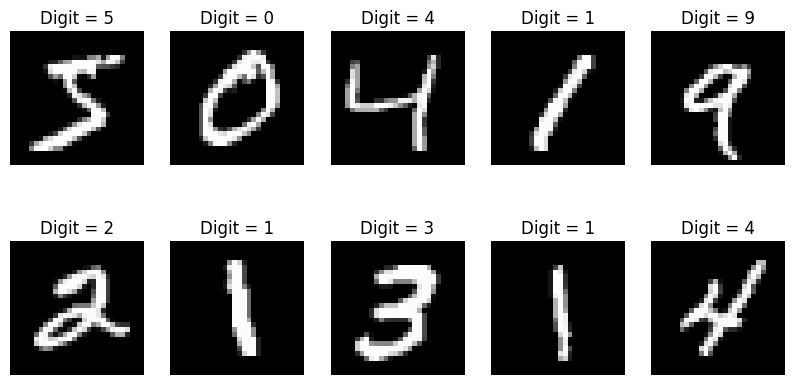

In [ ]:
# STEP 4: Display first 10 handwritten digits

plt.figure(figsize=(10,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_train[i], cmap='gray')

    plt.title("Digit = {}".format(y_train[i]))

    plt.axis('off')

plt.show()

STEP 5: Normalize pixel values

In [ ]:
# STEP 5: Normalize pixel values
# Convert values from 0-255 to 0-1

X_train = X_train / 255.0
X_test = X_test / 255.0

# STEP 5.1: Reshape images for CNN
# CNN expects input shape as:
# (samples, height, width, channels)

X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

print("New Training Shape :", X_train.shape)
print("New Testing Shape  :", X_test.shape)

New Training Shape : (60000, 28, 28, 1)
New Testing Shape  : (10000, 28, 28, 1)


 STEP 6: Create Convolutional Neural Network (CNN)

In [ ]:
# STEP 6: Create Convolutional Neural Network (CNN)

model = tf.keras.Sequential([

    # First Convolution Layer
    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    # First Pooling Layer
    tf.keras.layers.MaxPooling2D((2,2)),

    # Second Convolution Layer
    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    # Second Pooling Layer
    tf.keras.layers.MaxPooling2D((2,2)),

    # Convert feature maps to 1D vector
    tf.keras.layers.Flatten(),

    # Hidden Layer
    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    # Output Layer (10 digits: 0-9)
    tf.keras.layers.Dense(
        10,
        activation='softmax'
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


 STEP 7: Configure training settings

In [ ]:
# STEP 7: Configure training settings

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully")

Model Compiled Successfully


STEP 8: Train CNN Model

In [ ]:
# STEP 8: Train CNN Model

history = model.fit(
    X_train,
    y_train,
    epochs=3,
    validation_split=0.1
)

Epoch 1/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 48s 27ms/step - accuracy: 0.9575 - loss: 0.1392 - val_accuracy: 0.9845 - val_loss: 0.0530
Epoch 2/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 82s 27ms/step - accuracy: 0.9867 - loss: 0.0448 - val_accuracy: 0.9892 - val_loss: 0.0360
Epoch 3/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 44s 26ms/step - accuracy: 0.9903 - loss: 0.0305 - val_accuracy: 0.9893 - val_loss: 0.0348


STEP 9: Test the model on unseen data

In [ ]:
# STEP 9: Test the model on unseen data

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("\nTest Accuracy =", test_accuracy*100,"%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9903 - loss: 0.0272

Test Accuracy = 99.02999997138977 %


STEP 10: Upload image from your computer

In [ ]:
# STEP 10: Upload image from your computer

from google.colab import files

uploaded = files.upload()

# Get uploaded filename

filename = list(uploaded.keys())[0]

print("Uploaded File:", filename)

Saving Copilot_20260627_093434.png to Copilot_20260627_093434.png
Uploaded File: Copilot_20260627_093434.png


Image Size: (1024, 1024)


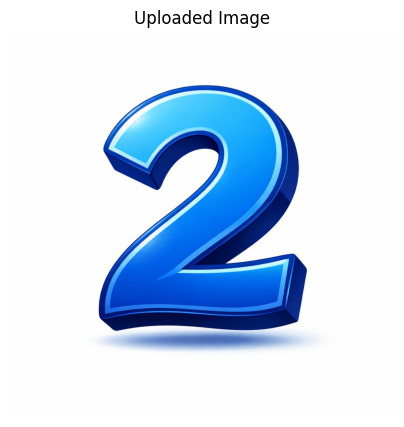

In [ ]:
# STEP 11: Display uploaded image

from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(filename)

print("Image Size:", img.size)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title("Uploaded Image")
plt.axis('off')
plt.show()


STEP 12: Convert image to grayscale

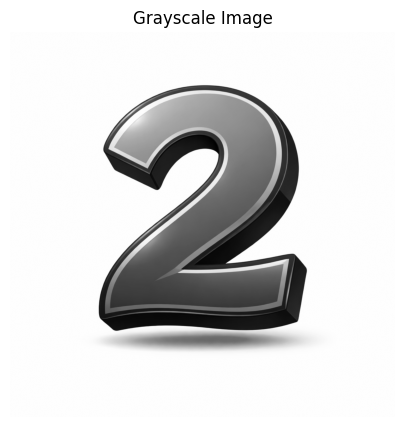

In [ ]:
# STEP 12: Convert image to grayscale

img = img.convert('L')

plt.figure(figsize=(5,5))
plt.imshow(img, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')
plt.show()

STEP 13: Resize image

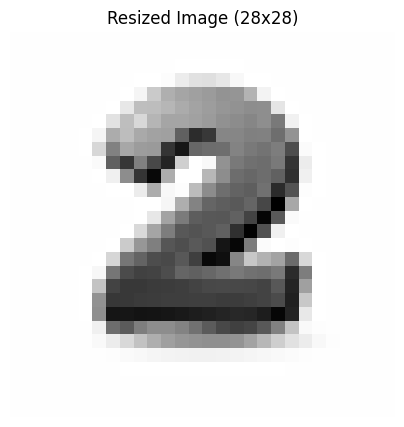

In [ ]:
# STEP 13: Resize image

img = img.resize((28,28))

plt.figure(figsize=(5,5))
plt.imshow(img, cmap='gray')
plt.title("Resized Image (28x28)")
plt.axis('off')
plt.show()

 STEP 14:Convert uploaded image into NumPy array

Original Shape : (28, 28)


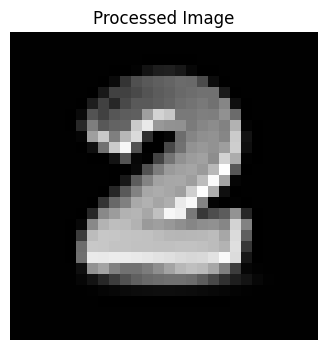

CNN Input Shape : (1, 28, 28, 1)


In [ ]:
# Convert uploaded image into NumPy array

import numpy as np

img_array = np.array(img)

print("Original Shape :", img_array.shape)


# Convert pixel values from 0-255 to 0-1

img_array = img_array / 255.0

# Invert colors
# MNIST expects white digit on black background
# Most uploaded images have black digit on white background

img_array = 1 - img_array

# Display processed image

import matplotlib.pyplot as plt

plt.figure(figsize=(4,4))
plt.imshow(img_array, cmap='gray')
plt.title("Processed Image")
plt.axis('off')
plt.show()

# Reshape image for CNN input
# CNN expects input shape:
# (batch_size, height, width, channels)

img_input = img_array.reshape(1, 28, 28, 1)

print("CNN Input Shape :", img_input.shape)


STEP 15: Predict digit

In [18]:
# STEP 15: Predict digit

prediction = model.predict(img_input)

predicted_digit = np.argmax(prediction)

confidence = np.max(prediction) * 100

print("Predicted Digit :", predicted_digit)
print("Confidence      : {:.2f}%".format(confidence))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Predicted Digit : 2
Confidence      : 85.86%
